In [1]:
# Import pandas for handling tabular data
import pandas as pd

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Load the built-in breast cancer dataset
from sklearn.datasets import load_breast_cancer

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import evaluation metrics for classification
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame containing the input features
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Add the target column
df["Target"] = cancer.target

# Display the first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names, data types, and non-null values
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness e

In [4]:
# Display descriptive statistics for numerical columns
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
# Display the number of examples in each class
print("Target class counts:")
print(df["Target"].value_counts())

# Display the meaning of each numeric target
print("\nTarget names:")
print(cancer.target_names)

# In this dataset:
# 0 = malignant
# 1 = benign

Target class counts:
Target
1    357
0    212
Name: count, dtype: int64

Target names:
['malignant' 'benign']


In [6]:
# X contains the input features
X = df.drop(columns=["Target"])

# y contains the target labels
y = df["Target"]

# Display the shapes of X and y
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [7]:
# Split the data into training and testing sets
# 80% is used for training
# 20% is used for testing
# stratify=y preserves class proportions
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the number of samples in each set
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [8]:
# Create a Decision Tree Classification model
model = DecisionTreeClassifier(
    criterion="gini",  # Use Gini impurity for splitting
    max_depth=4,       # Limit the maximum tree depth
    random_state=42    # Make results reproducible
)

# Display the model configuration
model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

In [9]:
# Train the Decision Tree using the training data
model.fit(X_train, y_train)

# Display a confirmation message
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [10]:
# Predict the classes for the test dataset
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("Predicted numeric classes:")
print(y_pred[:10])

# Convert numeric predictions into class names
predicted_labels = [
    cancer.target_names[label]
    for label in y_pred[:10]
]

print("\nPredicted class names:")
print(predicted_labels)

Predicted numeric classes:
[0 1 0 1 0 1 1 0 0 0]

Predicted class names:
[np.str_('malignant'), np.str_('benign'), np.str_('malignant'), np.str_('benign'), np.str_('malignant'), np.str_('benign'), np.str_('benign'), np.str_('malignant'), np.str_('malignant'), np.str_('malignant')]


In [11]:
# Create a DataFrame to compare actual and predicted classes
comparison = pd.DataFrame({
    "Actual": [
        cancer.target_names[label]
        for label in y_test
    ],
    "Predicted": [
        cancer.target_names[label]
        for label in y_pred
    ],
    "Correct": y_test.to_numpy() == y_pred
})

# Display the first 15 predictions
comparison.head(15)

,Actual,Predicted,Correct
0,malignant,malignant,True
1,benign,benign,True
2,malignant,malignant,True
3,benign,benign,True
4,malignant,malignant,True
5,benign,benign,True
6,benign,benign,True
7,malignant,malignant,True
8,malignant,malignant,True
9,malignant,malignant,True


In [12]:
# Calculate the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Accuracy:", accuracy)

# Display accuracy as a percentage
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9385964912280702
Accuracy: 93.86%


In [13]:
# Calculate precision for the benign class (label 1)
precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

# Calculate recall for the benign class
recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

# Calculate the F1-score for the benign class
f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

# Display the metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1-Score: 0.951048951048951


In [14]:
# Display precision, recall, F1-score, and support
# for both malignant and benign classes

print(
    classification_report(
        y_test,
        y_pred,
        target_names=cancer.target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



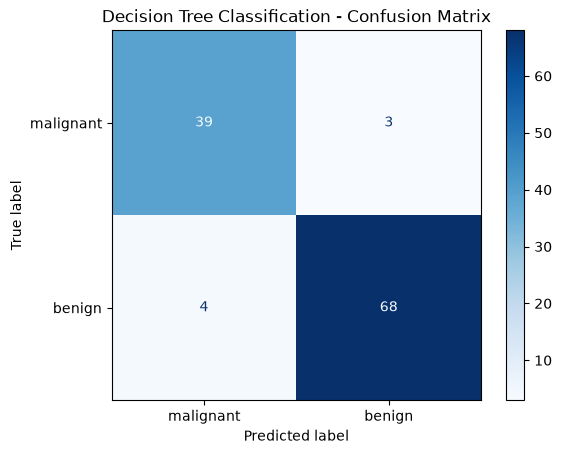

In [15]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a visualization of the confusion matrix
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

# Plot the confusion matrix
cm_display.plot(cmap="Blues")

# Add a title
plt.title("Decision Tree Classification - Confusion Matrix")

# Display the plot
plt.show()

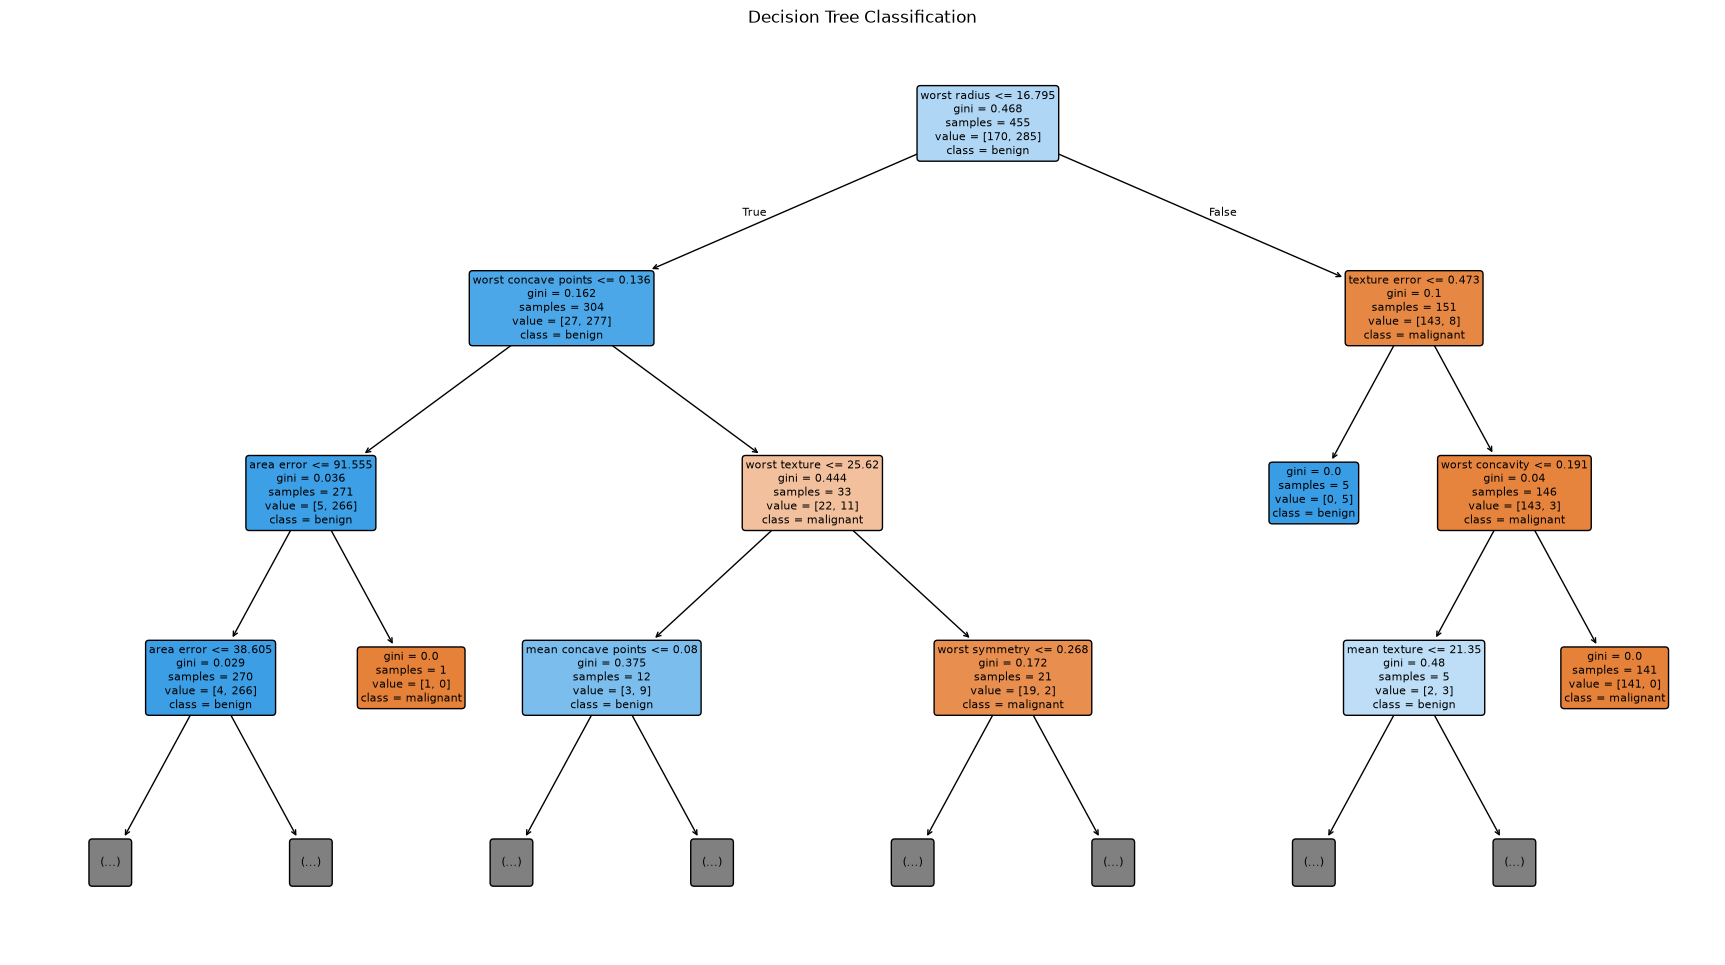

In [16]:
# Set the figure size
plt.figure(figsize=(22, 12))

# Visualize the trained Decision Tree
plot_tree(
    model,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

# Add a title
plt.title("Decision Tree Classification")

# Display the tree
plt.show()

In [17]:
# Display the final model performance
print("DECISION TREE CLASSIFICATION SUMMARY")
print("------------------------------------")

print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1-Score  : {f1:.2%}")

print("\nModel:", type(model).__name__)
print("Maximum depth:", model.max_depth)
print("Splitting criterion:", model.criterion)

DECISION TREE CLASSIFICATION SUMMARY
------------------------------------
Accuracy  : 93.86%
Precision : 95.77%
Recall    : 94.44%
F1-Score  : 95.10%

Model: DecisionTreeClassifier
Maximum depth: 4
Splitting criterion: gini
